In [ ]:
from google.colab import drive


In [ ]:
drive.mount("/content/drive")

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import matthews_corrcoef, roc_curve
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression, SGDClassifier




In [ ]:
df1= pd.read_csv("/content/drive/MyDrive/diabetes_012_health_indicators_BRFSS2021.csv")
df2= pd.read_csv("/content/drive/MyDrive/diabetes_binary_5050split_health_indicators_BRFSS2021.csv")
df3=pd.read_csv("/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2021.csv")

In [ ]:
#Normalizing into Binary and Renaming
df1['Diabetes_012'] = df1['Diabetes_012'].replace({1: 1, 2: 1, 0: 0})
df1.rename(columns={'Diabetes_012': 'Diabetes_binary'}, inplace=True)

In [ ]:
#Combining Datasets
df = pd.concat([df1, df2, df3], ignore_index=True)


**PRE-PROCESSING**

In [ ]:
df

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,0,1.0,1,15.0,1.0,0.0,0.0,0,1,...,1,0.0,5.0,10.0,20.0,0.0,0,11,4.0,5.0
1,1.0,1,0.0,1,28.0,0.0,0.0,1.0,0,1,...,1,0.0,2.0,0.0,0.0,0.0,0,11,4.0,3.0
2,1.0,1,1.0,1,33.0,0.0,0.0,0.0,1,1,...,1,0.0,2.0,10.0,0.0,0.0,0,9,4.0,7.0
3,1.0,0,1.0,1,29.0,0.0,1.0,1.0,1,1,...,1,0.0,5.0,0.0,30.0,1.0,1,12,3.0,4.0
4,0.0,0,0.0,1,24.0,1.0,0.0,0.0,0,0,...,1,0.0,3.0,0.0,0.0,1.0,1,13,5.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539887,1.0,1,1.0,1,21.0,0.0,0.0,0.0,1,1,...,1,0.0,4.0,0.0,0.0,0.0,1,10,2.0,3.0
539888,0.0,1,0.0,1,25.0,1.0,0.0,0.0,1,1,...,0,1.0,2.0,20.0,0.0,0.0,0,3,4.0,5.0
539889,0.0,0,1.0,1,31.0,0.0,0.0,0.0,1,1,...,1,0.0,2.0,0.0,0.0,0.0,1,7,6.0,10.0
539890,0.0,1,0.0,1,24.0,0.0,0.0,0.0,1,1,...,1,0.0,2.0,0.0,0.0,0.0,1,10,4.0,6.0


In [ ]:
df1.head

<bound method NDFrame.head of         Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0                   0.0       0       1.0          1  15.0     1.0     0.0   
1                   1.0       1       0.0          1  28.0     0.0     0.0   
2                   1.0       1       1.0          1  33.0     0.0     0.0   
3                   1.0       0       1.0          1  29.0     0.0     1.0   
4                   0.0       0       0.0          1  24.0     1.0     0.0   
...                 ...     ...       ...        ...   ...     ...     ...   
236373              1.0       1       1.0          1  21.0     0.0     0.0   
236374              0.0       1       0.0          1  25.0     1.0     0.0   
236375              0.0       0       1.0          1  31.0     0.0     0.0   
236376              0.0       1       0.0          1  24.0     0.0     0.0   
236377              0.0       0       1.0          1  32.0     0.0     0.0   

        HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                        0.0             0       1  ...              1   
1                        1.0             0       1  ...              1   
2                        0.0             1       1  ...              1   
3                        1.0             1       1  ...              1   
4                        0.0             0       0  ...              1   
...                      ...           ...     ...  ...            ...   
236373                   0.0             1       1  ...              1   
236374                   0.0             1       1  ...              0   
236375                   0.0             1       1  ...              1   
236376                   0.0             1       1  ...              1   
236377                   0.0             1       0  ...              1   

        NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  Age  \
0               0.0      5.0      10.0      20.0       0.0    0   11   
1               0.0      2.0       0.0       0.0       0.0    0   11   
2               0.0      2.0      10.0       0.0       0.0    0    9   
3               0.0      5.0       0.0      30.0       1.0    1   12   
4               0.0      3.0       0.0       0.0       1.0    1   13   
...             ...      ...       ...       ...       ...  ...  ...   
236373          0.0      4.0       0.0       0.0       0.0    1   10   
236374          1.0      2.0      20.0       0.0       0.0    0    3   
236375          0.0      2.0       0.0       0.0       0.0    1    7   
236376          0.0      2.0       0.0       0.0       0.0    1   10   
236377          0.0      1.0       2.0       2.0       0.0    0    6   

        Education  Income  
0             4.0     5.0  
1             4.0     3.0  
2             4.0     7.0  
3             3.0     4.0  
4             5.0     6.0  
...           ...     ...  
236373        2.0     3.0  
236374        4.0     5.0  
236375        6.0    10.0  
236376        4.0     6.0  
236377        6.0     6.0  

[236378 rows x 22 columns]>

In [ ]:
df1.tail

<bound method NDFrame.tail of         Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0                   0.0       0       1.0          1  15.0     1.0     0.0   
1                   1.0       1       0.0          1  28.0     0.0     0.0   
2                   1.0       1       1.0          1  33.0     0.0     0.0   
3                   1.0       0       1.0          1  29.0     0.0     1.0   
4                   0.0       0       0.0          1  24.0     1.0     0.0   
...                 ...     ...       ...        ...   ...     ...     ...   
236373              1.0       1       1.0          1  21.0     0.0     0.0   
236374              0.0       1       0.0          1  25.0     1.0     0.0   
236375              0.0       0       1.0          1  31.0     0.0     0.0   
236376              0.0       1       0.0          1  24.0     0.0     0.0   
236377              0.0       0       1.0          1  32.0     0.0     0.0   

        HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                        0.0             0       1  ...              1   
1                        1.0             0       1  ...              1   
2                        0.0             1       1  ...              1   
3                        1.0             1       1  ...              1   
4                        0.0             0       0  ...              1   
...                      ...           ...     ...  ...            ...   
236373                   0.0             1       1  ...              1   
236374                   0.0             1       1  ...              0   
236375                   0.0             1       1  ...              1   
236376                   0.0             1       1  ...              1   
236377                   0.0             1       0  ...              1   

        NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  Age  \
0               0.0      5.0      10.0      20.0       0.0    0   11   
1               0.0      2.0       0.0       0.0       0.0    0   11   
2               0.0      2.0      10.0       0.0       0.0    0    9   
3               0.0      5.0       0.0      30.0       1.0    1   12   
4               0.0      3.0       0.0       0.0       1.0    1   13   
...             ...      ...       ...       ...       ...  ...  ...   
236373          0.0      4.0       0.0       0.0       0.0    1   10   
236374          1.0      2.0      20.0       0.0       0.0    0    3   
236375          0.0      2.0       0.0       0.0       0.0    1    7   
236376          0.0      2.0       0.0       0.0       0.0    1   10   
236377          0.0      1.0       2.0       2.0       0.0    0    6   

        Education  Income  
0             4.0     5.0  
1             4.0     3.0  
2             4.0     7.0  
3             3.0     4.0  
4             5.0     6.0  
...           ...     ...  
236373        2.0     3.0  
236374        4.0     5.0  
236375        6.0    10.0  
236376        4.0     6.0  
236377        6.0     6.0  

[236378 rows x 22 columns]>

In [ ]:
col=['Education','Income','DiffWalk','HvyAlcoholConsump','Stroke','BMI']
df_=df.drop(col,axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539892 entries, 0 to 539891
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       539892 non-null  float64
 1   HighBP                539892 non-null  int64  
 2   HighChol              539892 non-null  float64
 3   CholCheck             539892 non-null  int64  
 4   BMI                   539892 non-null  float64
 5   Smoker                539892 non-null  float64
 6   Stroke                539892 non-null  float64
 7   HeartDiseaseorAttack  539892 non-null  float64
 8   PhysActivity          539892 non-null  int64  
 9   Fruits                539892 non-null  int64  
 10  Veggies               539892 non-null  int64  
 11  HvyAlcoholConsump     539892 non-null  int64  
 12  AnyHealthcare         539892 non-null  int64  
 13  NoDocbcCost           539892 non-null  float64
 14  GenHlth               539892 non-null  float64
 15  

In [ ]:
df.isnull().sum()

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [ ]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(228792, 22)

In [ ]:

df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,228792.000000,228792.000000,228792.000000,228792.000000,228792.000000,228792.000000,228792.000000,228792.000000,228792.000000,228792.000000,...,228792.000000,228792.000000,228792.000000,228792.000000,228792.000000,228792.000000,228792.000000,228792.000000,228792.000000,228792.000000
mean,0.170216,0.435277,0.414914,0.962075,29.192000,0.426846,0.041435,0.091865,0.765569,0.607180,...,0.960326,0.067970,2.535478,4.174512,3.998125,0.164958,0.475659,7.890272,5.099269,6.816541
std,0.375823,0.495794,0.492708,0.191016,6.674682,0.494621,0.199295,0.288836,0.423644,0.488378,...,0.195192,0.251695,1.029231,8.076653,8.460657,0.371143,0.499408,3.251530,0.954488,2.382078
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,5.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,28.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,32.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,4.000000,3.000000,0.000000,1.000000,10.000000,6.000000,9.000000
max,1.000000,1.000000,1.000000,1.000000,99.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,11.000000


In [ ]:
df.select_dtypes(include=["number"])

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,0,1.0,1,15.0,1.0,0.0,0.0,0,1,...,1,0.0,5.0,10.0,20.0,0.0,0,11,4.0,5.0
1,1.0,1,0.0,1,28.0,0.0,0.0,1.0,0,1,...,1,0.0,2.0,0.0,0.0,0.0,0,11,4.0,3.0
2,1.0,1,1.0,1,33.0,0.0,0.0,0.0,1,1,...,1,0.0,2.0,10.0,0.0,0.0,0,9,4.0,7.0
3,1.0,0,1.0,1,29.0,0.0,1.0,1.0,1,1,...,1,0.0,5.0,0.0,30.0,1.0,1,12,3.0,4.0
4,0.0,0,0.0,1,24.0,1.0,0.0,0.0,0,0,...,1,0.0,3.0,0.0,0.0,1.0,1,13,5.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539692,0.0,1,0.0,1,27.0,0.0,0.0,0.0,1,1,...,1,0.0,3.0,0.0,0.0,0.0,0,11,6.0,5.0
539715,0.0,1,1.0,1,34.0,0.0,0.0,0.0,0,1,...,1,1.0,4.0,5.0,30.0,1.0,0,10,4.0,4.0
539814,0.0,1,1.0,1,24.0,0.0,0.0,0.0,1,1,...,1,0.0,3.0,10.0,5.0,0.0,0,8,6.0,7.0
539815,0.0,1,1.0,1,35.0,0.0,0.0,0.0,0,0,...,1,0.0,2.0,0.0,30.0,1.0,0,9,5.0,6.0


Outliers for Diabetes_binary:
    Diabetes_binary
1               1.0
2               1.0
3               1.0
7               1.0
10              1.0


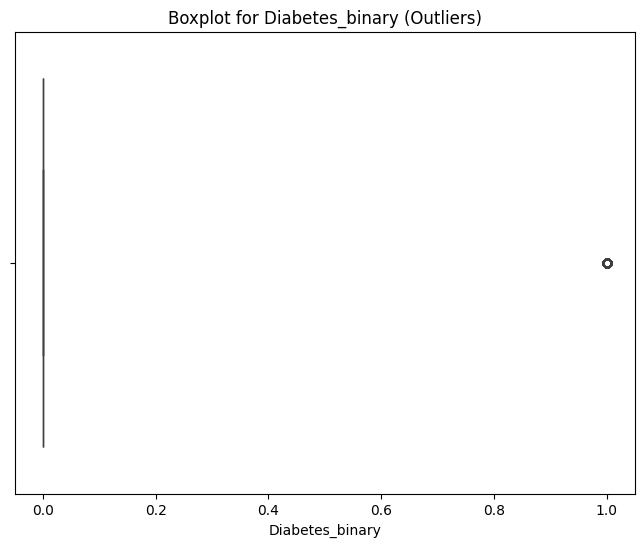

Outliers for HighBP:
Empty DataFrame
Columns: [HighBP]
Index: []


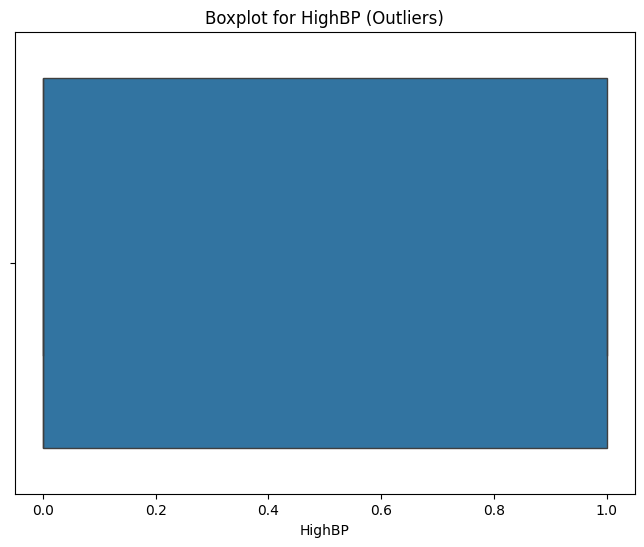

Outliers for HighChol:
Empty DataFrame
Columns: [HighChol]
Index: []


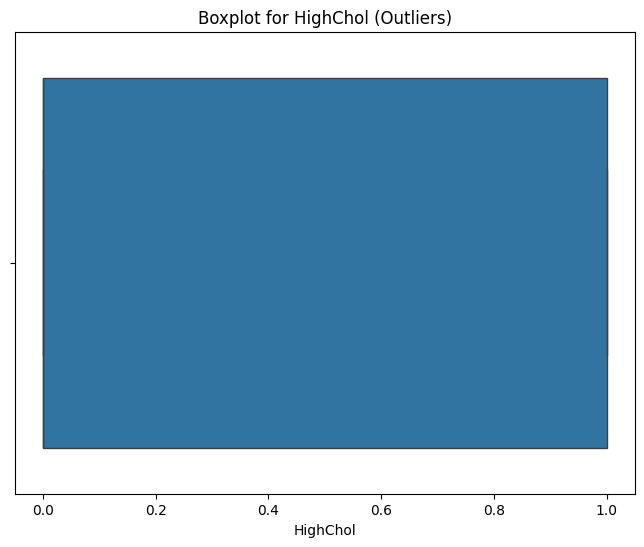

Outliers for CholCheck:
     CholCheck
44           0
201          0
209          0
301          0
371          0


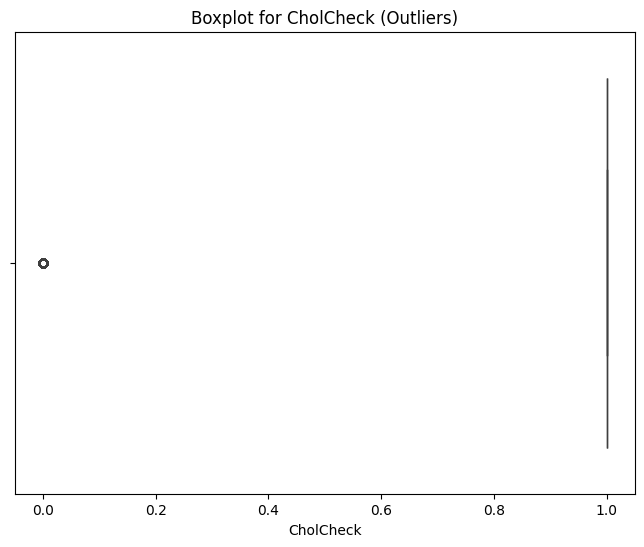

Outliers for BMI:
      BMI
31   45.0
79   43.0
95   44.0
158  43.0
172  50.0


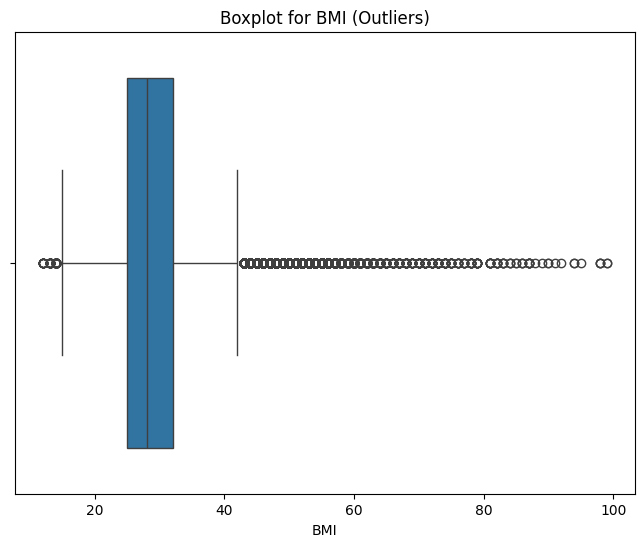

Outliers for Smoker:
Empty DataFrame
Columns: [Smoker]
Index: []


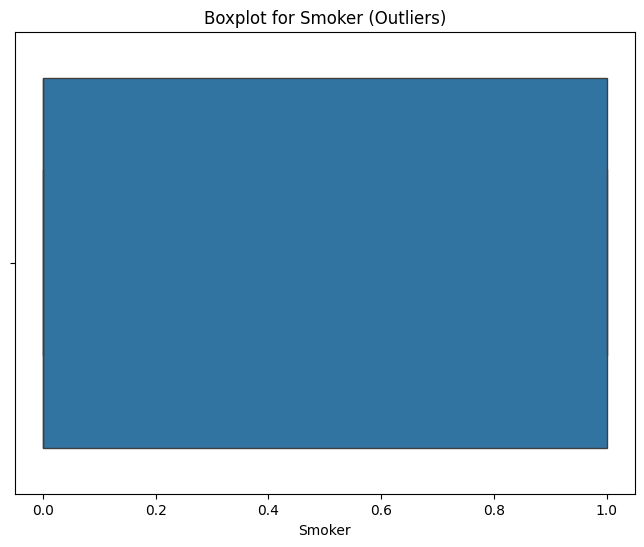

Outliers for Stroke:
    Stroke
3      1.0
21     1.0
52     1.0
87     1.0
93     1.0


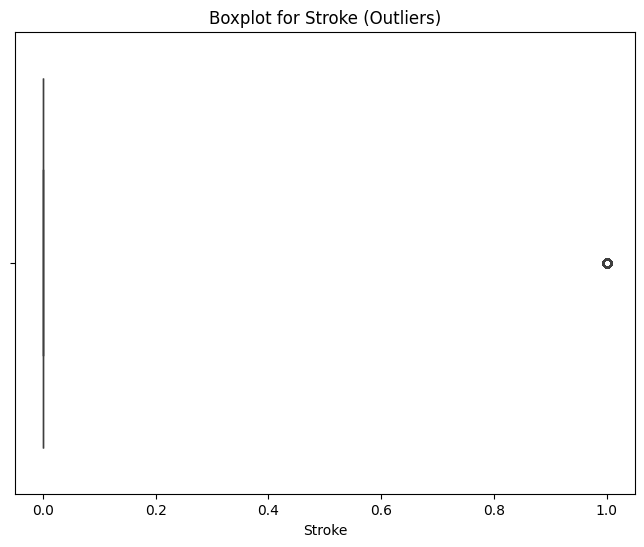

Outliers for HeartDiseaseorAttack:
    HeartDiseaseorAttack
1                    1.0
3                    1.0
7                    1.0
22                   1.0
34                   1.0


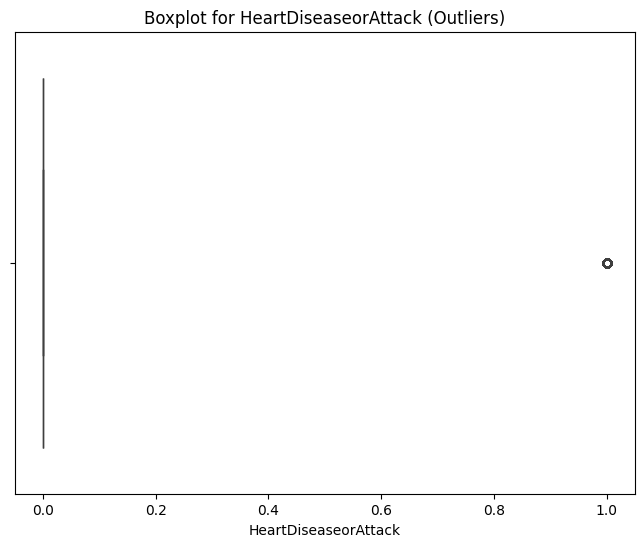

Outliers for PhysActivity:
   PhysActivity
0             0
1             0
4             0
6             0
7             0


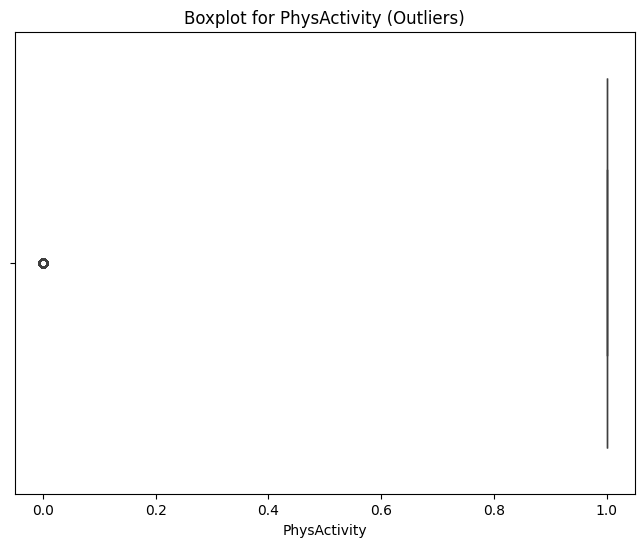

Outliers for Fruits:
Empty DataFrame
Columns: [Fruits]
Index: []


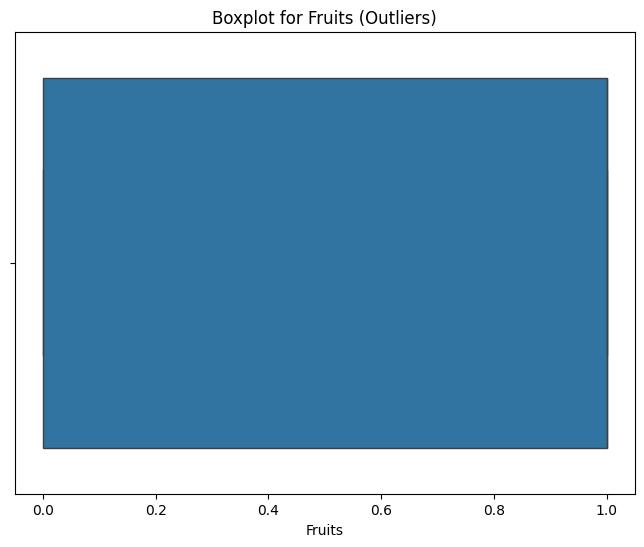

Outliers for Veggies:
    Veggies
1         0
4         0
9         0
15        0
16        0


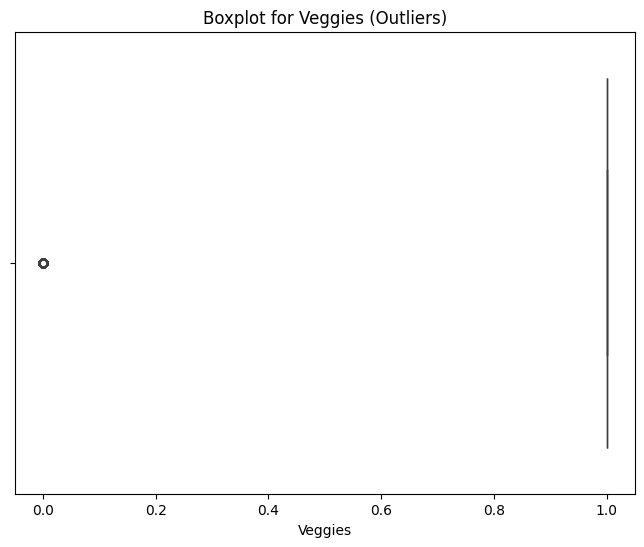

Outliers for HvyAlcoholConsump:
    HvyAlcoholConsump
34                  1
48                  1
55                  1
76                  1
79                  1


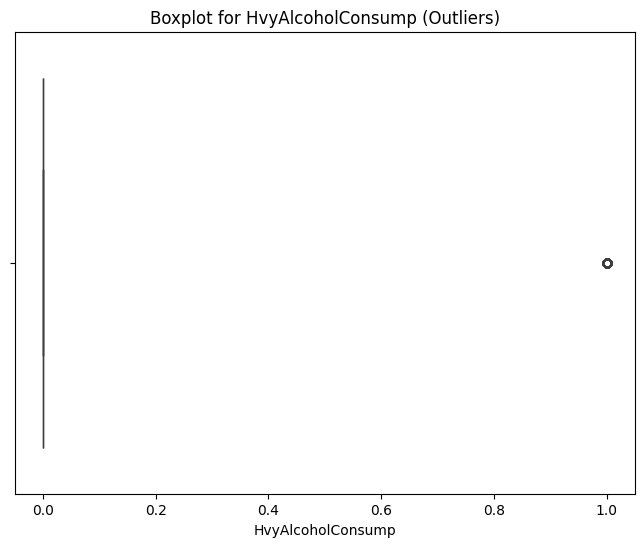

Outliers for AnyHealthcare:
     AnyHealthcare
168              0
183              0
239              0
319              0
337              0


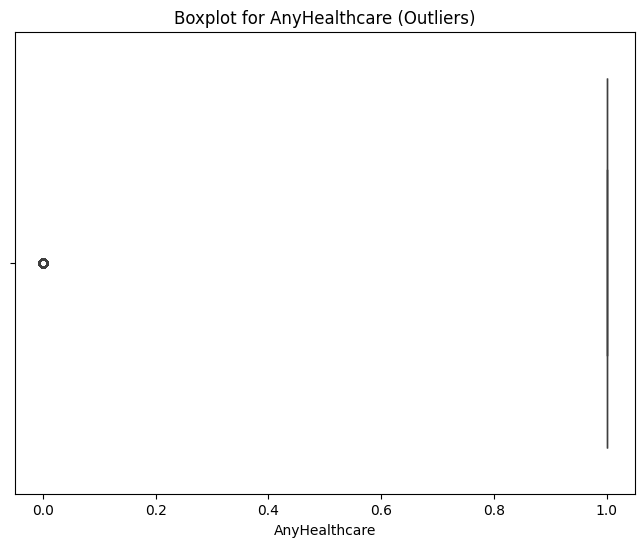

Outliers for NoDocbcCost:
    NoDocbcCost
29          1.0
41          1.0
45          1.0
54          1.0
90          1.0


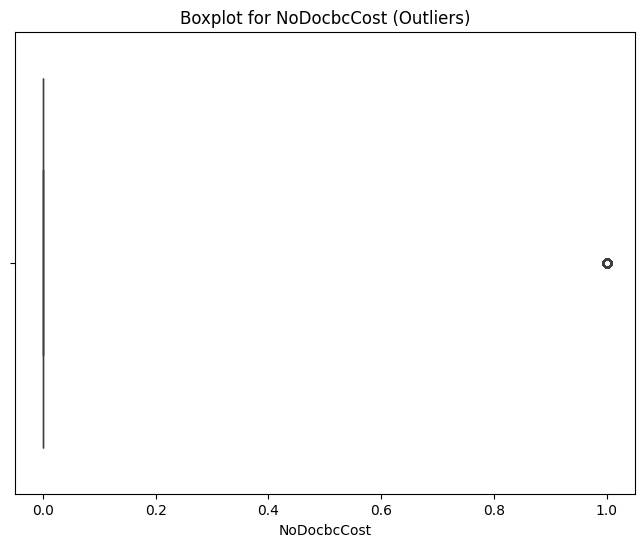

Outliers for GenHlth:
    GenHlth
0       5.0
3       5.0
32      5.0
41      5.0
55      5.0


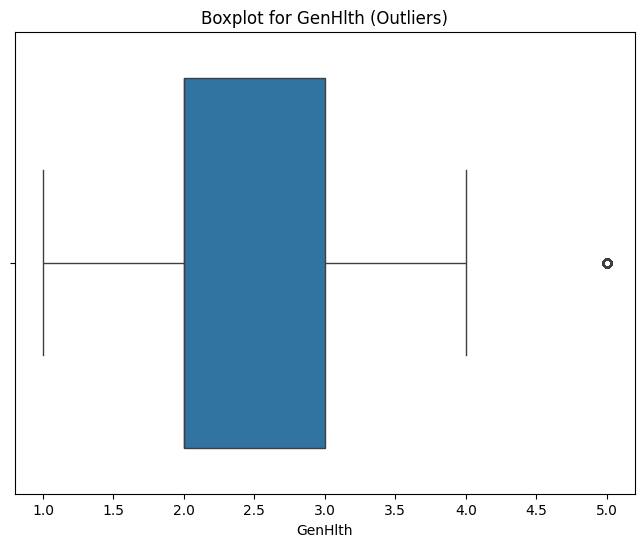

Outliers for MentHlth:
    MentHlth
6       25.0
29      30.0
30      25.0
38      14.0
40      20.0


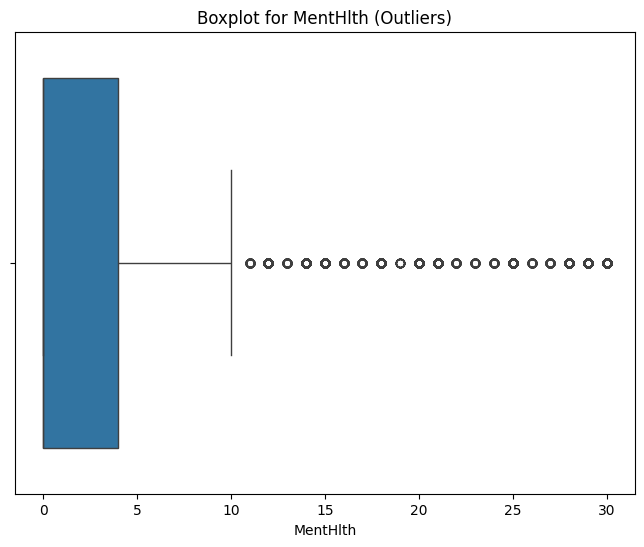

Outliers for PhysHlth:
    PhysHlth
0       20.0
3       30.0
5       25.0
12      30.0
13      10.0


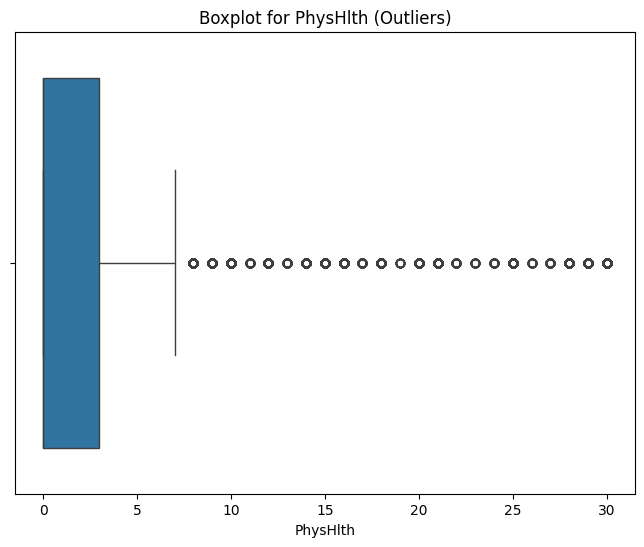

Outliers for DiffWalk:
    DiffWalk
3        1.0
4        1.0
5        1.0
14       1.0
25       1.0


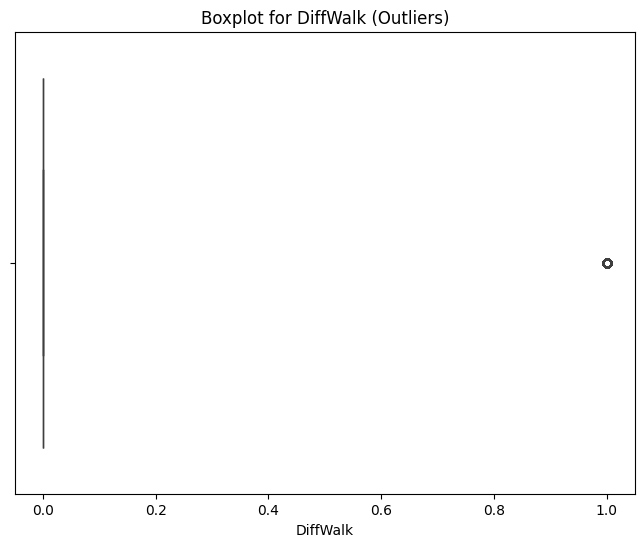

Outliers for Sex:
Empty DataFrame
Columns: [Sex]
Index: []


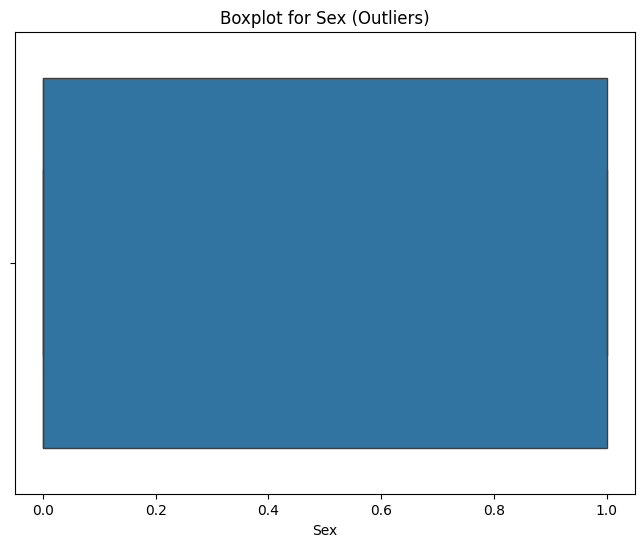

Outliers for Age:
Empty DataFrame
Columns: [Age]
Index: []


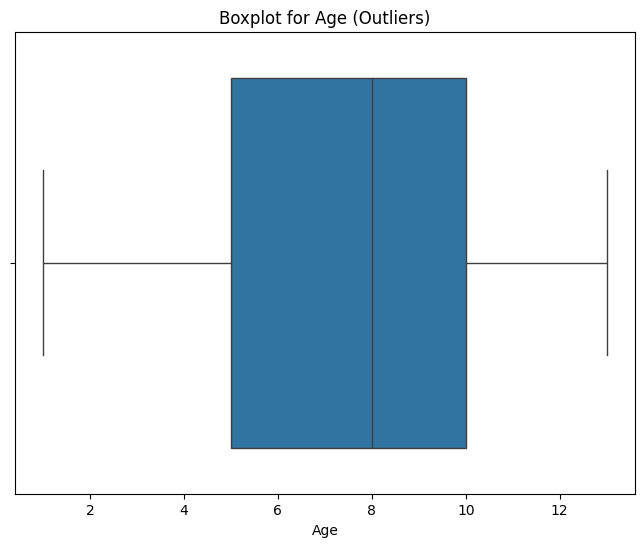

Outliers for Education:
Empty DataFrame
Columns: [Education]
Index: []


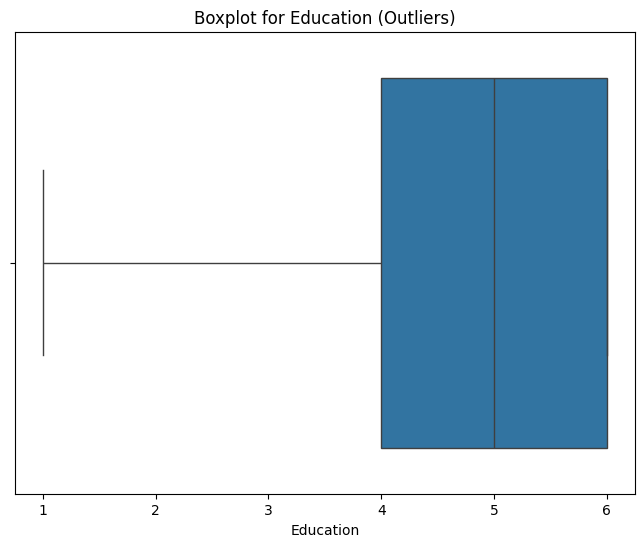

Outliers for Income:
Empty DataFrame
Columns: [Income]
Index: []


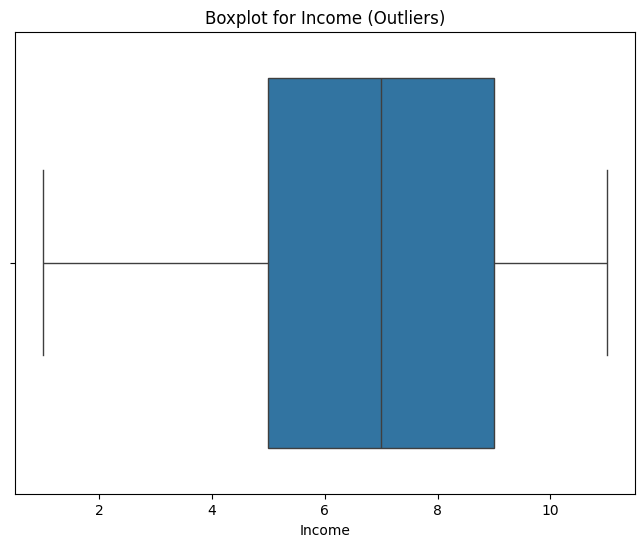

Original shape: (228792, 22)
Shape after removing outliers: (64777, 22)


In [ ]:
# List of columns to check for outliers (excluding the target variable if applicable)
columns_to_check = df.columns.tolist()

# Function to show outliers using IQR
def show_outliers(df, columns_to_check):
    for col in columns_to_check:
        if df[col].dtype in [np.int64, np.float64]:  # Check if the column is numeric
            # Calculate Q1 (25th percentile) and Q3 (75th percentile)
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1

            # Define the outlier bounds
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Identify outliers
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

            # Show outliers for the column
            print(f"Outliers for {col}:")
            print(outliers[[col]].head())  # Displaying top 5 outliers for brevity

            # Plotting boxplot to visualize the outliers
            plt.figure(figsize=(8, 6))
            sns.boxplot(x=df[col])
            plt.title(f"Boxplot for {col} (Outliers)")
            plt.show()

# Show outliers
show_outliers(df, columns_to_check)

# Function to remove outliers using IQR
def remove_outliers(df, columns_to_check):
    df_cleaned = df.copy()  # Create a copy of the dataframe to preserve the original

    for col in columns_to_check:
        if df_cleaned[col].dtype in [np.int64, np.float64]:  # Check if the column is numeric
            # Calculate Q1 (25th percentile) and Q3 (75th percentile)
            Q1 = df_cleaned[col].quantile(0.25)
            Q3 = df_cleaned[col].quantile(0.75)
            IQR = Q3 - Q1

            # Define the outlier bounds
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Remove outliers
            df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]

    return df_cleaned

# Remove outliers from the dataset
df_cleaned = remove_outliers(df, columns_to_check)

# Check the shape before and after removing outliers
print(f"Original shape: {df.shape}")
print(f"Shape after removing outliers: {df_cleaned.shape}")



**EXPLORATORYY DATA ANALYSIS**

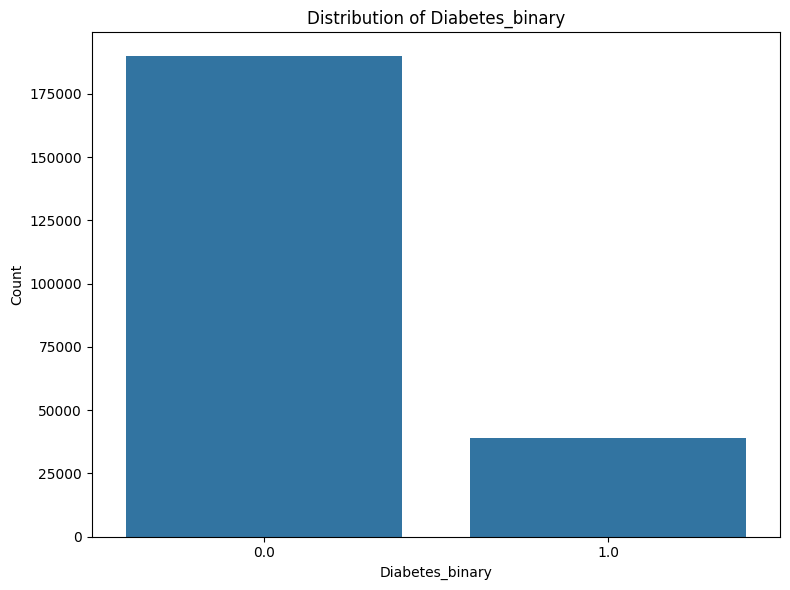

In [ ]:
# Plot distribution of the target variable 'Diabetes_binary'
plt.figure(figsize=(8, 6), dpi=100)
sns.countplot(x='Diabetes_binary', data=df)
plt.title('Distribution of Diabetes_binary')
plt.xlabel('Diabetes_binary')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

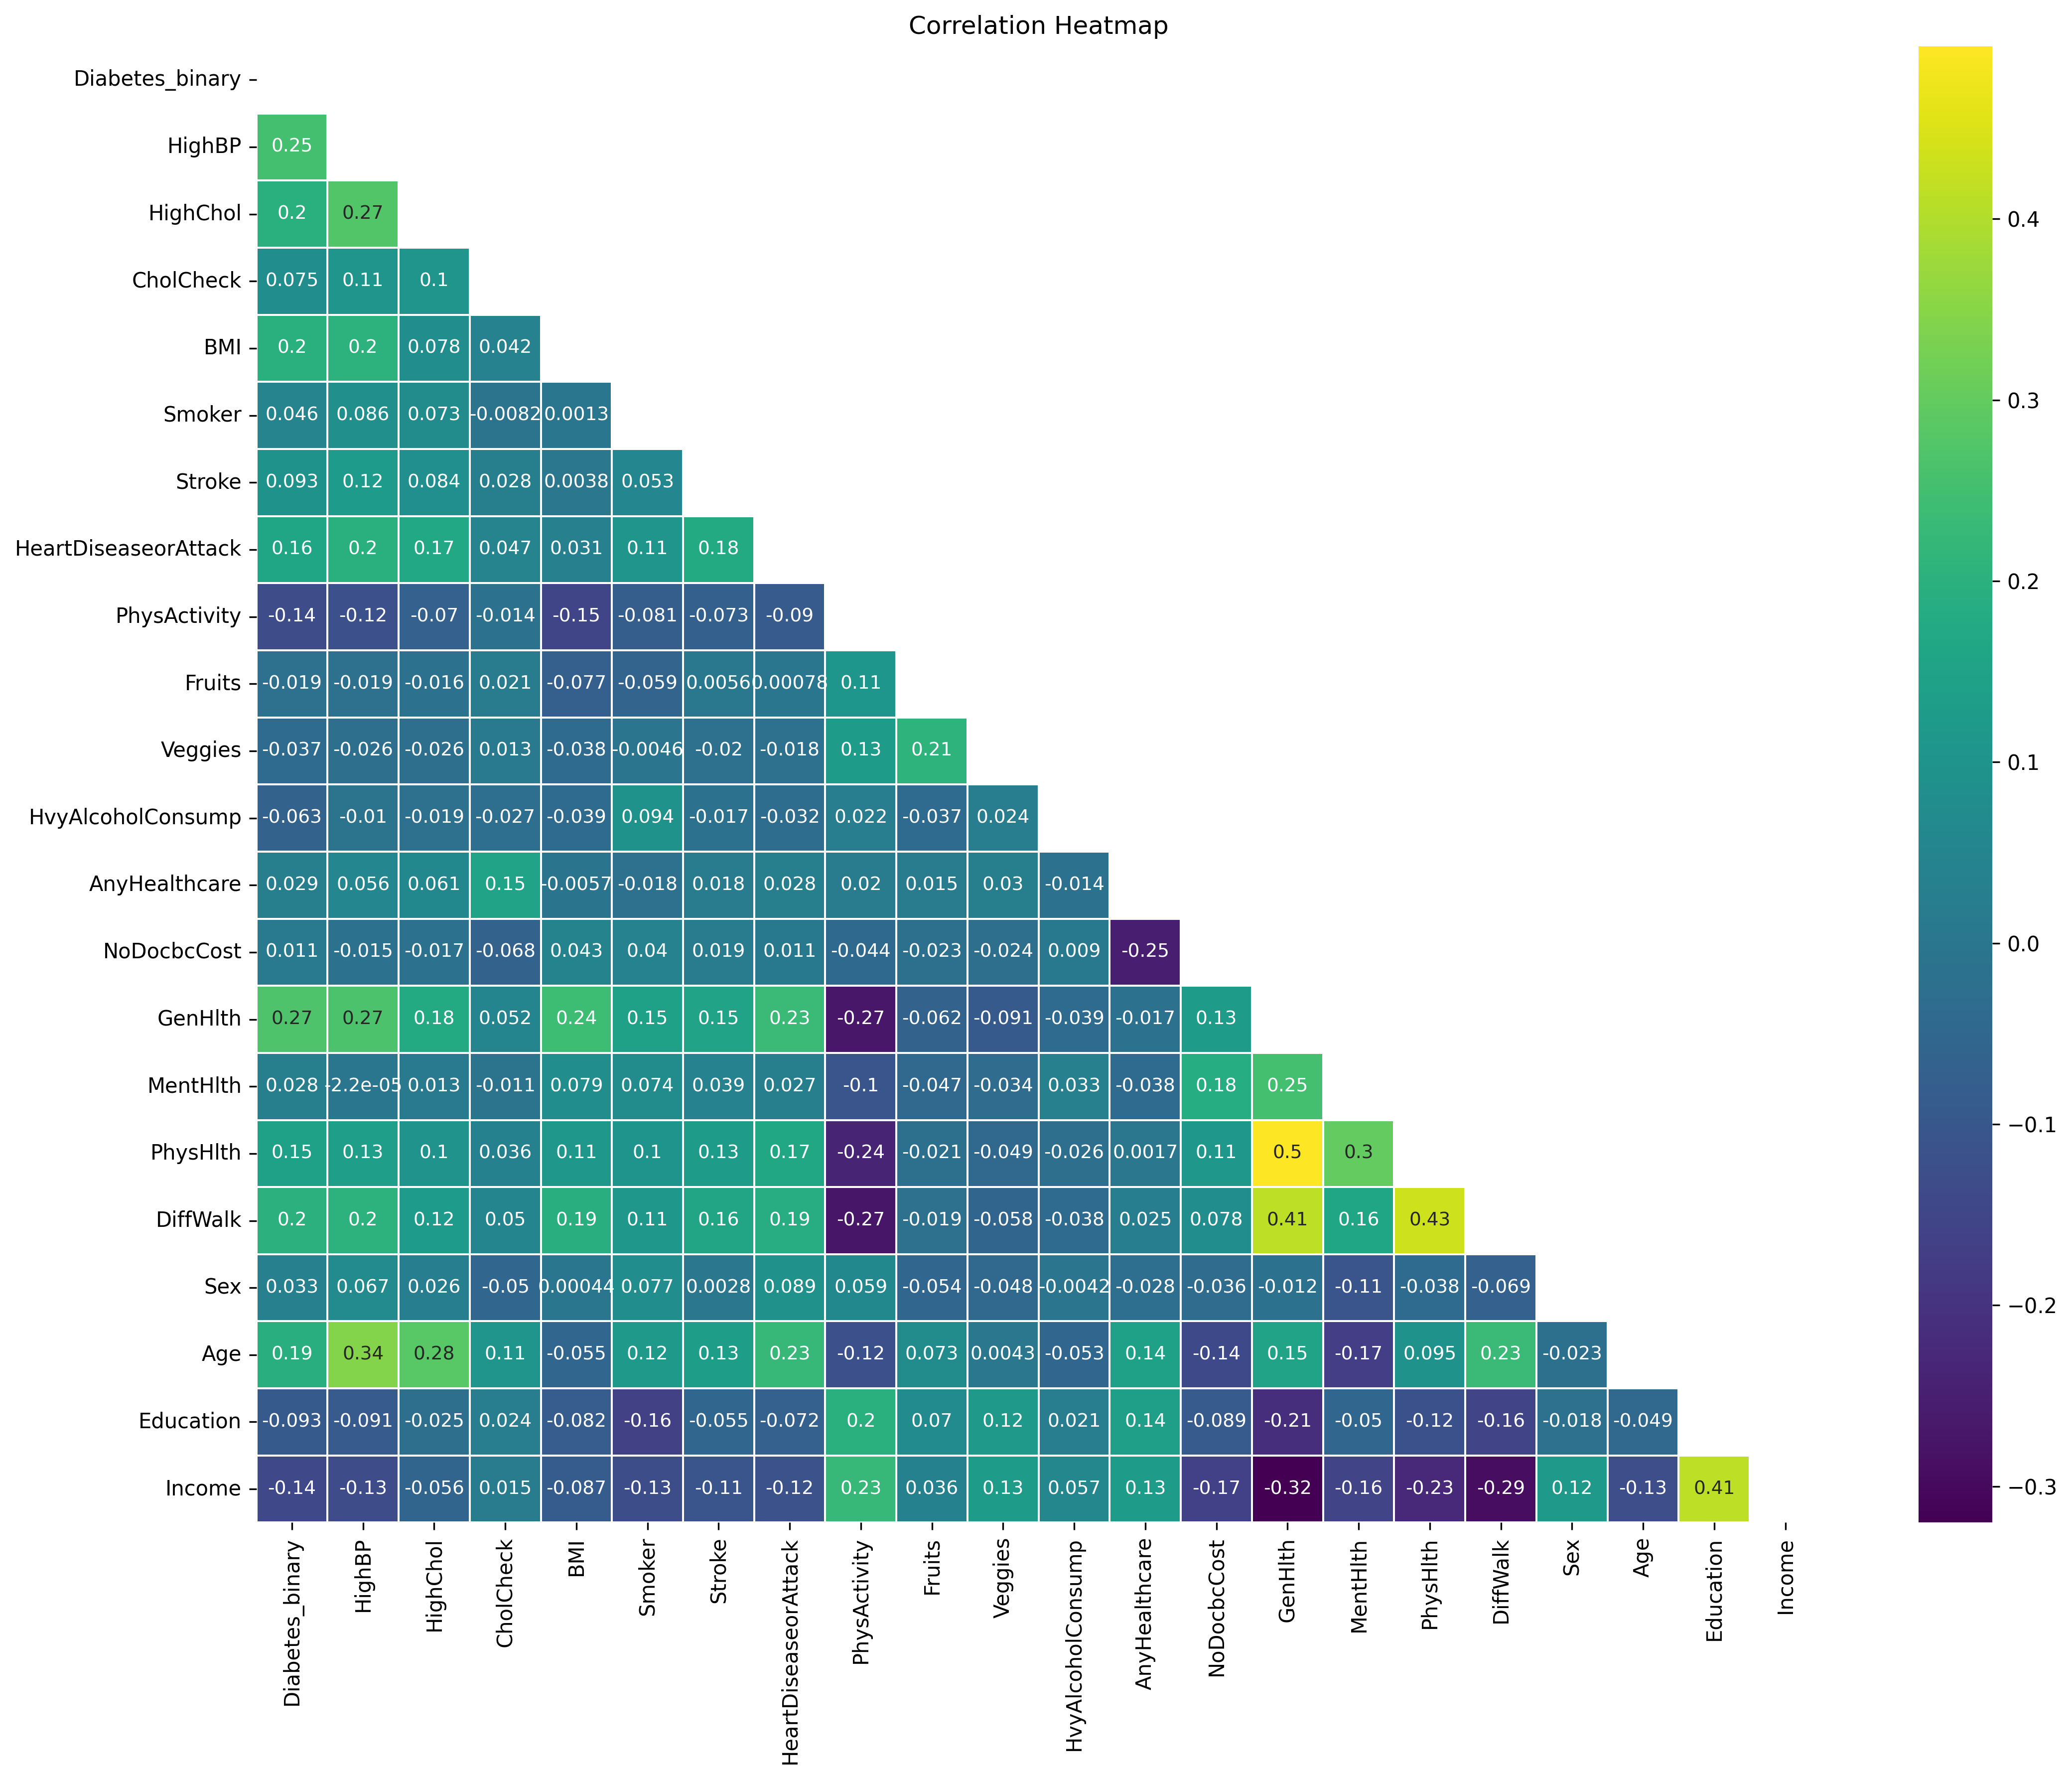

In [ ]:
# Plot correlation heatmap
plt.figure(figsize=(15, 12), dpi=300)
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, mask=mask, cmap='viridis', linewidth=.5, annot_kws={'size': 9})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

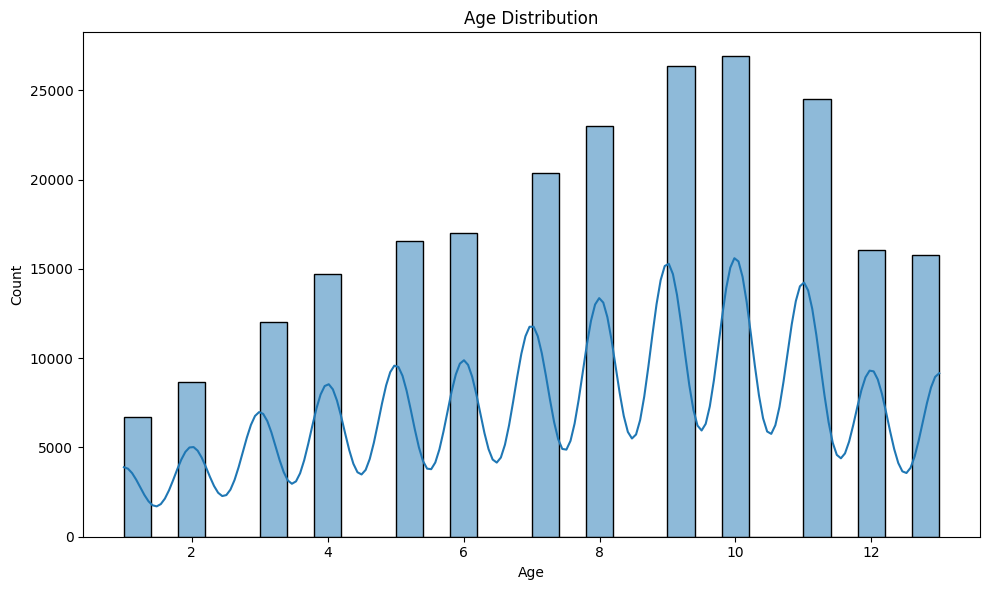

In [ ]:
# Plot age distribution
plt.figure(figsize=(10, 6), dpi=100)
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

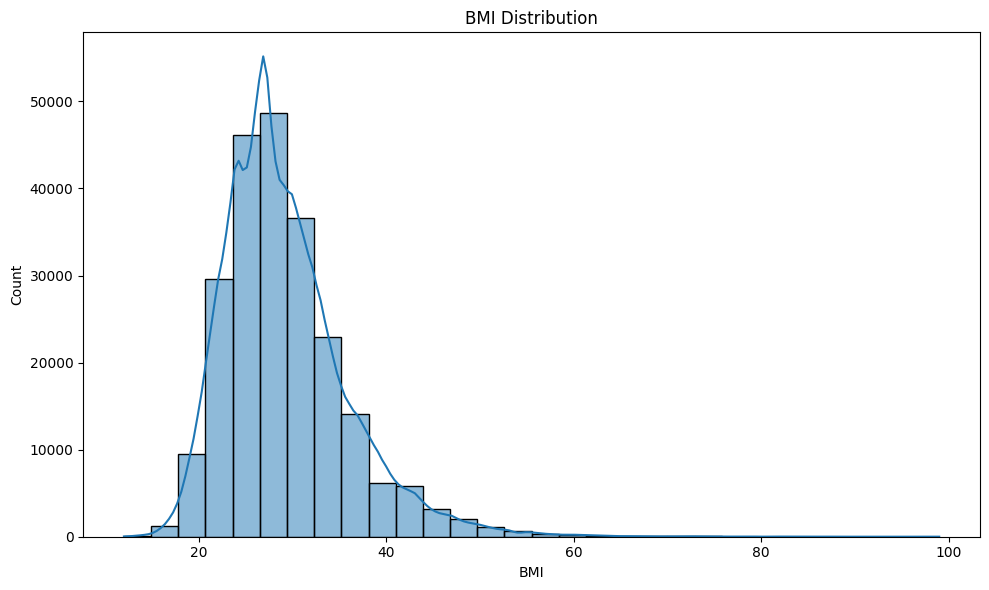

In [ ]:
# Plot BMI Distribution
plt.figure(figsize=(10, 6), dpi=100)
sns.histplot(df['BMI'], bins=30, kde=True)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

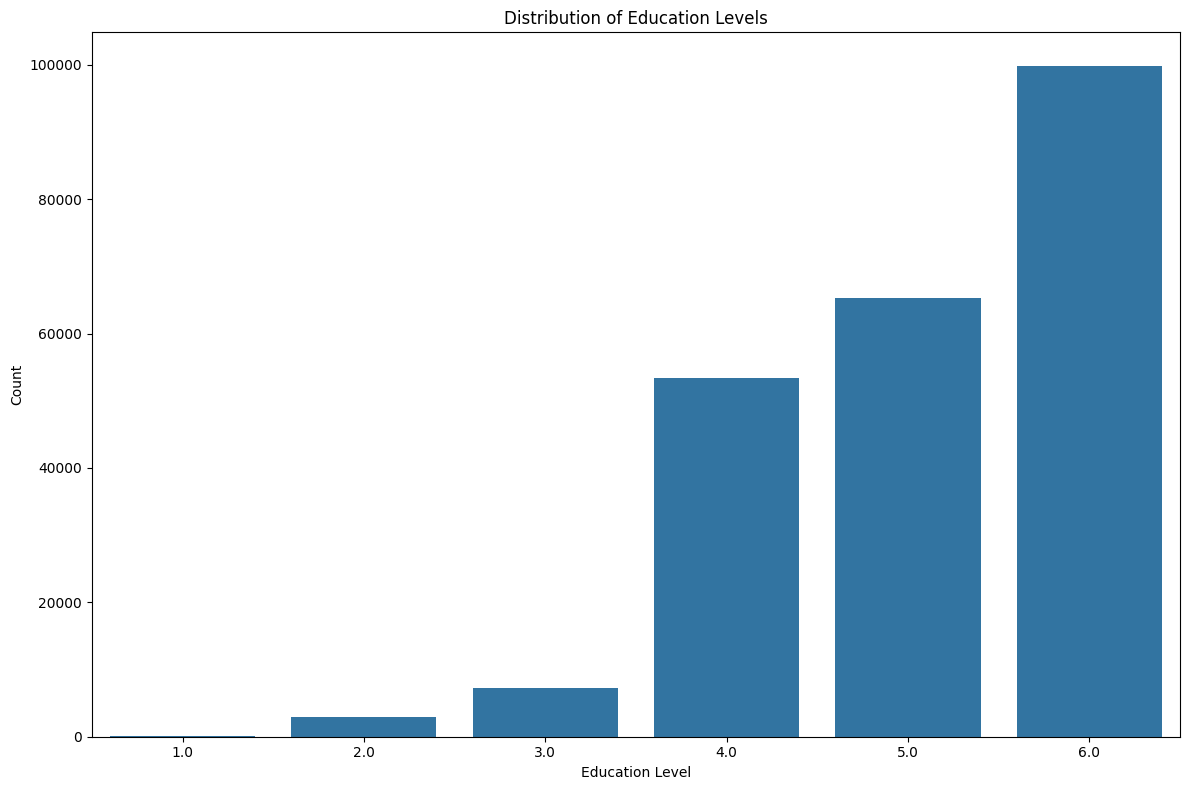

In [ ]:
# Plot Distribution of Education Levels
plt.figure(figsize=(12, 8), dpi=100)
sns.countplot(x='Education', data=df)
plt.title('Distribution of Education Levels')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
fig = px.box(df, x='Diabetes_binary', y='Income', color='Diabetes_binary',
                labels={'Diabetes_binary': 'Diabetes Binary', 'Income': 'Income Level'},
                title='Income Distribution by Diabetes Binary')
fig.show()

**TRAINING & TESTING MODEL**

In [ ]:
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Define models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(kernel='linear', probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}
results = {}

**RANDOM FOREST**

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
# Function to evaluate models
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else [0] * len(y_test)

    # Calculate metrics
    train_score = model.score(X_train, y_train)
    test_score = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob) if hasattr(model, "predict_proba") else None
    mcc = matthews_corrcoef(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    # Plot ROC Curve
    if hasattr(model, "predict_proba"):
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve for {model.__class__.__name__}')
        plt.legend()
        plt.show()

    # Print results
    print(f"\nModel: {model.__class__.__name__}")
    print(f"Training Score: {train_score:.4f}")
    print(f"Testing Score: {test_score:.4f}")
    if roc_auc is not None:
        print(f"ROC AUC Score: {roc_auc:.4f}")
    print(f"Matthews Correlation Coefficient: {mcc:.4f}")
    print("\nClassification Report:")
    print(report)


Evaluating Random Forest...


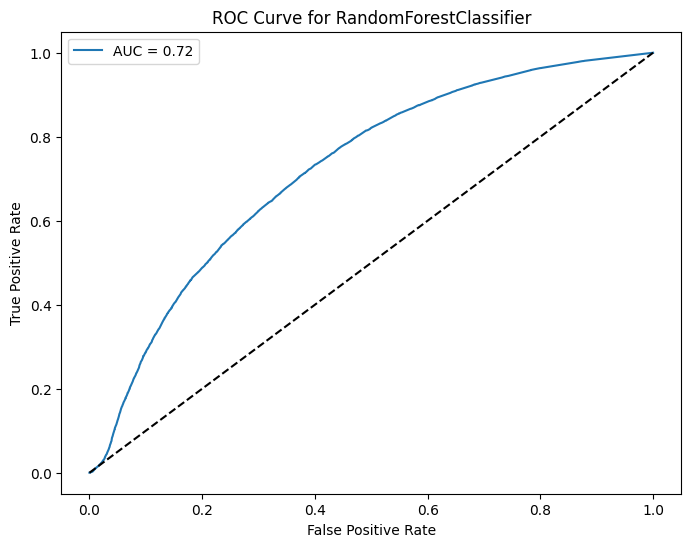


Model: RandomForestClassifier
Training Score: 0.9760
Testing Score: 0.8075
ROC AUC Score: 0.7216
Matthews Correlation Coefficient: 0.1455

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.94      0.89     37921
         1.0       0.36      0.16      0.22      7838

    accuracy                           0.81     45759
   macro avg       0.60      0.55      0.56     45759
weighted avg       0.76      0.81      0.78     45759


Evaluating Gradient Boosting...


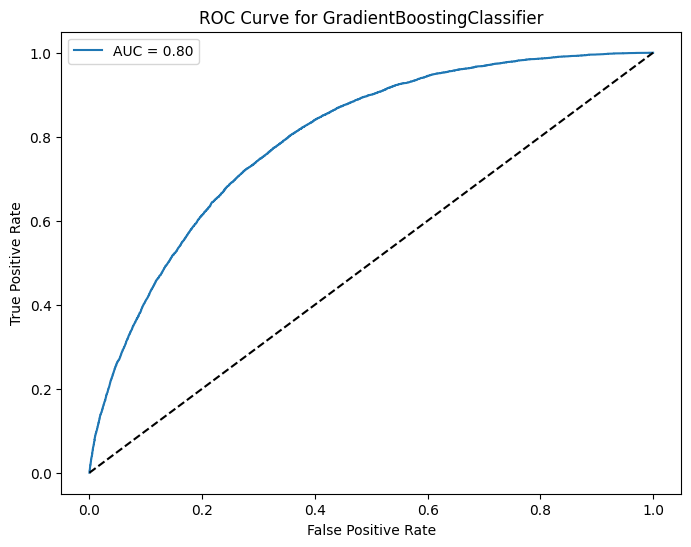


Model: GradientBoostingClassifier
Training Score: 0.8379
Testing Score: 0.8354
ROC AUC Score: 0.7967
Matthews Correlation Coefficient: 0.2404

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.97      0.91     37921
         1.0       0.57      0.16      0.25      7838

    accuracy                           0.84     45759
   macro avg       0.71      0.57      0.58     45759
weighted avg       0.80      0.84      0.80     45759


Evaluating Support Vector Machine...


In [ ]:
# Evaluate each model
for name, model in models.items():
    print(f"\nEvaluating {name}...")
    evaluate_model(model, X_train, X_test, y_train, y_test)

In [ ]:

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
report = classification_report(y_test, y_pred)


# Print results
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(report)


**Gradient Boosting Classsifier**

In [ ]:
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
report = classification_report(y_test, y_pred)

In [ ]:
# Print results
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(report)

**SVM MODEL**

In [ ]:
#SVM Classifier
model = SVC(kernel='rbf', probability=True, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
report = classification_report(y_test, y_pred)

# Print results
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(report)

**LOGISTIC REGRESSION**

In [ ]:
# Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
# Print results
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(report)


In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Prepare the data (using your existing df_)
X = df_.drop('Diabetes_binary', axis=1)
y = df_['Diabetes_binary']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize models (using the ones you imported)
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(random_state=42)),
    'SVM': make_pipeline(StandardScaler(), SVC(probability=True, random_state=42)),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    'Naive Bayes': GaussianNB()
}

# Function to plot ROC curve
def plot_roc_curve(fpr, tpr, model_name):
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")

# Initialize plot
plt.figure(figsize=(10, 8))

# Evaluate each model
for name, model in models.items():
    print(f"\n========== {name} ==========")

    # 10-fold cross validation
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f"10-Fold CV AUC Scores: {cv_scores}")
    print(f"Mean AUC: {cv_scores.mean():.2f} (±{cv_scores.std():.2f})")

    # Fit model and get predictions
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plot_roc_curve(fpr, tpr, name)

plt.show()